# HybridAgent — Exploración interactiva

Este notebook carga el paclet HVA y recorre las funciones principales de `HybridAgent`:
`AgentId`, accessors, actualizaciones inmutables y hash estructural.

## 1 · Cargar el paclet

In [32]:
PacletDirectoryLoad["/workspaces/hva-framework/paclet"];
Needs["HVA`"]

## 2 · Construir un agente de prueba

HybridAgent["thermostat" @ off]
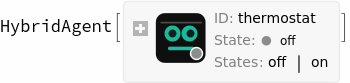

In [35]:
(* Agente termostat mínimo *)
Spec = HybridAgent["thermostat",
  States       -> {"off", "on"},
  Vars         -> {temp},
  Dynamics     -> <|
    "off" -> {Derivative[1][temp] == 0},
    "on"  -> {Derivative[1][temp] == 5 - temp}
  |>,
  Guards       -> {
    <|"from" -> "off", "to" -> "on",  "condition" -> temp < 18|>,
    <|"from" -> "on",  "to" -> "off", "condition" -> temp > 22|>
  },
  Invariants   -> {0 <= temp <= 30},
  InitialState -> "off",
  InitialValues -> <|temp -> 15|>
]

In [37]:
(* Verificar que se construyó correctamente *)
HybridAgentQ[Spec]

True

## 3 · `AgentId` — identificador del agente

```
AgentId::usage = "AgentId[a] devuelve el identificador del agente."
```

In [38]:
AgentId[Spec]

thermostat

In [40]:
(* Verificar tipo de retorno *)
StringQ[AgentId[Spec]]

True

Expected HybridAgent.
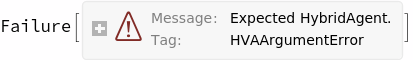

In [42]:
(* Error handling: non-HybridAgent *)
AgentId["not an agent"]

## 4 · Accessors completos

In [43]:
AgentStates[Spec]

{off, on}

In [44]:
AgentVars[Spec]

{temp}

In [45]:
AgentDynamics[Spec]

<|off -> {temp' == 0}, on -> {temp' == 5 - temp}|>

In [46]:
AgentGuards[Spec]

{<|from -> off, to -> on, condition -> temp < 18|>, 
 
>   <|from -> on, to -> off, condition -> temp > 22|>}

In [63]:
AgentCurrentState[Spec]

off

In [48]:
AgentValuation[Spec]

<|temp -> 15|>

In [49]:
AgentValuation[Spec][temp]

15

## 5 · Actualizaciones inmutables

Cada `With*` devuelve un **nuevo** agente sin modificar el original.

In [51]:
agent2 = WithCurrentState[Spec, "on"];
{AgentCurrentState[Spec], AgentCurrentState[agent2]}

{off, on}

In [53]:
Spec3 = WithValuation[agent2, <|temp -> 20|>];
AgentValuation[Spec3][temp]

20

In [55]:
Spec4 = AppendTrace[Spec3, "transitioned to on"];
AgentTrace[Spec4]

{transitioned to on}

## 6 · Hash estructural

`AgentStructuralHash` es determinístico e ignora campos runtime (`currentState`, `valuation`, `mailbox`, `trace`).

In [59]:
(* Mismo hash en dos instancias con distintos runtime fields *)
h1 = AgentStructuralHash[Spec3];
h2 = AgentStructuralHash[Spec4];
{h1, h2, h1 === h2}

{259865744861799748825303145939090130599, 259865744861799748825303145939090130599, True}

In [60]:
(* Hash cambia si se modifica la estructura *)
SpecMod = HybridAgent["thermostat",
  States       -> {"off", "on", "standby"},
  Vars         -> {temp},
  Dynamics     -> <|
    "off"     -> {Derivative[1][temp] == 0},
    "on"      -> {Derivative[1][temp] == 5 - temp},
    "standby" -> {Derivative[1][temp] == -0.1 * temp}
  |>,
  Guards       -> {},
  Invariants   -> {},
  InitialState -> "off",
  InitialValues -> <|temp -> 15|>
];
AgentStructuralHash[Spec3] =!= AgentStructuralHash[SpecMod]

True